# 抽样与极限定理

## Goal
固定一个采样机制，区分单项波动、样本均值抽样波动和模拟图本身的波动。先修第十九至二十一讲；完整推导在lecture.pdf，独立步骤在lab.pdf。

保留的实际运行中，Bernoulli均值的批间样本标准差由n=4的0.219221降至n=256的0.026518。相同64行若只有8个独立群组，批间标准差约0.155665。Cauchy四组均值IQR均约2。这些是固定种子的有限模拟，不是极限定理证明或现实模型性能。

## Setup
在本单元目录启动。使用environment.yml；Notebook只读取本单元合成输入，不访问网络或个人文件。R=4000表示完整实验重复次数，n表示每次的样本量。固定图题和手算要求默认配置，首格会明确核验；另存JSON并用脚本--spec参数进行其他设定的实验。

In [1]:
import sys, math, io
from fractions import Fraction
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import experiment as e
plt.rcParams.update({"font.size":11,"axes.spines.top":False,"axes.spines.right":False,"figure.facecolor":"white"})
def show(fig):
    fig.tight_layout(pad=1.5)
    buffer=io.BytesIO(); fig.savefig(buffer,format="png",dpi=130,bbox_inches="tight")
    plt.close(fig); display(Image(data=buffer.getvalue()))
print({"Python":sys.version.split()[0],"NumPy":np.__version__,"Matplotlib":matplotlib.__version__,"generator":"PCG64"})
spec=e.load_spec(); population=e.load_population()
e.require(spec == {"kind":"synthetic_sampling_demo","seed":22022,"repetitions":4000,"sizes":[4,16,64,256],"p_numerator":1,"p_denominator":4}, "This notebook uses the documented baseline. Run alternative JSON with the script --spec option and recompute its theory.")
e.require(population == [0,0,1,1], "This notebook uses the four-unit baseline population.")
print(spec)
print("Finite population values, identities retained:",population)

{'Python': '3.12.14', 'NumPy': '2.3.5', 'Matplotlib': '3.10.8', 'generator': 'PCG64'}
{'kind': 'synthetic_sampling_demo', 'seed': 22022, 'repetitions': 4000, 'sizes': [4, 16, 64, 256], 'p_numerator': 1, 'p_denominator': 4}
Finite population values, identities retained: [0, 0, 1, 1]


### Key Assumptions
主实验每个矩阵的一行是独立重新采集的一批n个观测，列位置服从同一指定分布。不同n使用不同种子重新生成；单独的运行均值图才使用前缀。群组复制有意破坏行内独立性。Pareto I只满足有限均值，Cauchy没有通常期望。不得以有限输出替代矩存在性或采样设计的判断。

## Steps
### 1. 四个数字，三种尺度
`variance_n`与`s2`使用不同分母，`estimated_se_iid`依赖独立同分布解释。

In [2]:
print(e.moments([0,0,0,1]))
print("True Bernoulli(1/4) SE for n=4:",math.sqrt(3)/8)
print("One observation:",e.moments([1]))
print("All-zero sample, not proof of p=0:",e.moments([0,0,0,0]))

{'n': 4, 'mean': 0.25, 'variance_n': 0.1875, 's2': 0.25, 's': 0.5, 'estimated_se_iid': 0.25}
True Bernoulli(1/4) SE for n=4: 0.21650635094610965
One observation: {'n': 1, 'mean': 1.0, 'variance_n': 0.0, 's2': None, 's': None, 'estimated_se_iid': None}
All-zero sample, not proof of p=0: {'n': 4, 'mean': 0.0, 'variance_n': 0.0, 's2': 0.0, 's': 0.0, 'estimated_se_iid': 0.0}


### 2. 先精确枚举，再看随机误差
Fraction保留完整质量和事件端点。CDF误差是连续正态CDF与离散CDF在跳跃两侧的最大差。

In [3]:
print("n=4 exact PMF:",[str(q) for q in e.binomial_exact(4)])
print("n     mean        variance        true SE      exact tail      Chebyshev      CDF error")
for n in spec["sizes"]:
    r=e.exact_mean_summary(n)
    print(n,r["mean_exact"],r["variance_exact"],f'{r["standard_error"]:.9f}',f'{r["tail_ge_epsilon"]:.9f}',f'{r["chebyshev_bound"]:.9f}',f'{r["normal_cdf_max_jump_error"]:.9f}')

n=4 exact PMF: ['81/256', '27/64', '27/128', '3/64', '1/256']
n     mean        variance        true SE      exact tail      Chebyshev      CDF error
4 1/4 3/64 0.216506351 0.578125000 1.000000000 0.238281250
16 1/4 3/256 0.108253175 0.386765623 1.000000000 0.130186175
64 1/4 3/1024 0.054126588 0.059030864 0.292968750 0.066647889
256 1/4 3/4096 0.027063294 0.000241382 0.073242188 0.033522982


### 3. 一条路径不是抽样分布
四条独立路径，种子220222至220225，长度4096；每条曲线使用自身前缀。即使有限图像平稳，也不能证明无限序列结论。

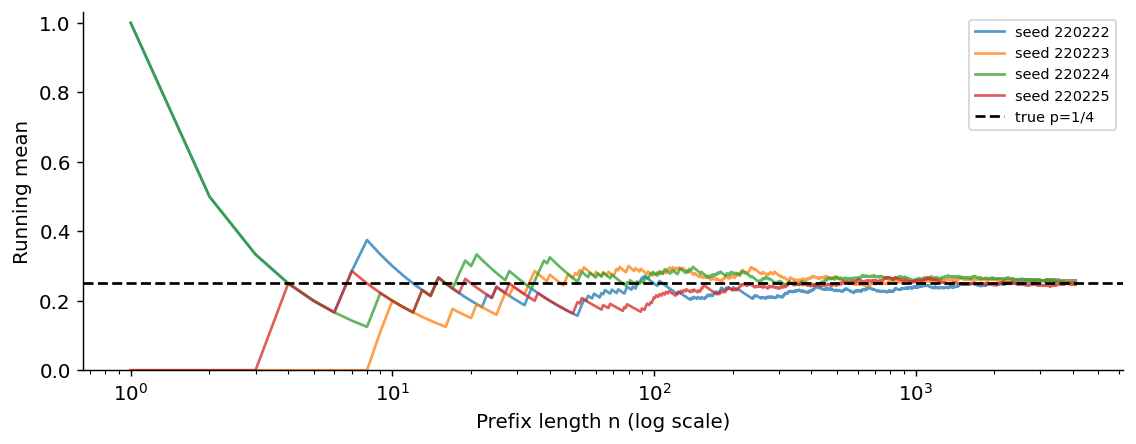

In [4]:
fig,ax=plt.subplots(figsize=(9,3.7)); ns=np.arange(1,4097)
for seed in range(220222,220226):
    rng=np.random.Generator(np.random.PCG64(seed))
    x=rng.binomial(1,.25,4096)
    ax.plot(ns,np.cumsum(x)/ns,label=f"seed {seed}",alpha=.75)
ax.axhline(.25,color="black",ls="--",label="true p=1/4")
ax.set(xscale="log",xlabel="Prefix length n (log scale)",ylabel="Running mean",ylim=(0,1.03))
ax.legend(fontsize=8); show(fig)

### 4. 固定n的4000批实验
每批求一次平均，得到4000个统计量。下面只在原始均值尺度上比较，不把它与标准化后的CLT形状混为一谈。

n    empirical SD of means      true SE
4 0.21922137349355125 0.21650635094610965
16 0.10762857150908231 0.10825317547305482
64 0.05399002521301968 0.05412658773652741
256 0.0265175046490801 0.027063293868263706


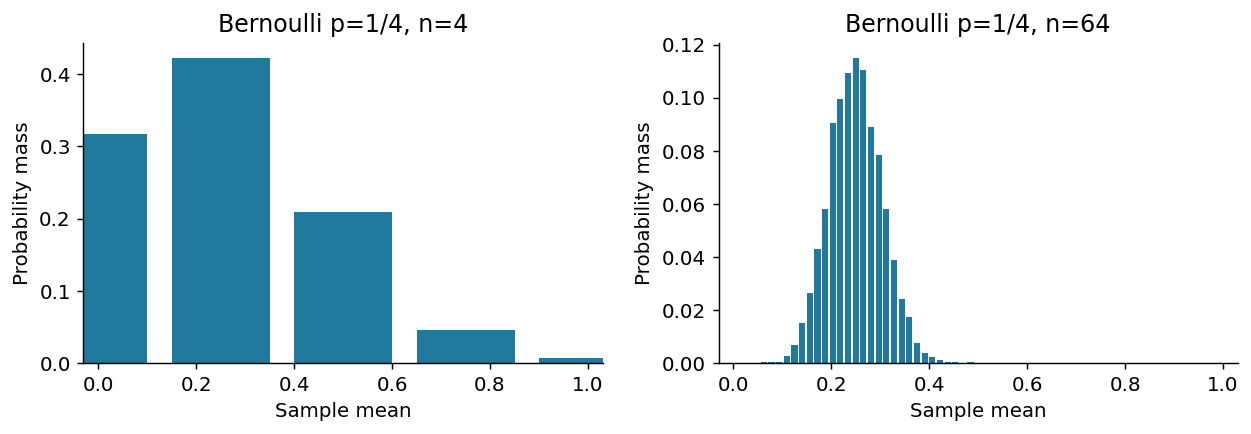

In [5]:
samples=e.sample_means(spec)
print("n    empirical SD of means      true SE")
for n in spec["sizes"]:
    print(n,e.moments(samples["bernoulli"][n])["s"],math.sqrt(3/(16*n)))
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for ax,n in zip(axes,[4,64]):
    k=np.rint(samples["bernoulli"][n]*n).astype(int)
    frequencies=np.bincount(k,minlength=n+1)/len(k)
    ax.bar(np.arange(n+1)/n,frequencies,width=.8/n,label="4000 replicated means",color="#217a9d")
    ax.set(xlim=(-.03,1.03),xlabel="Sample mean",ylabel="Probability mass",title=f"Bernoulli p=1/4, n={n}")
show(fig)

### 5. CLT比较CDF，不比较柱高和密度高
完整离散CDF在左右极端仍为0和1。图只显示中央区间，但未重新归一化。

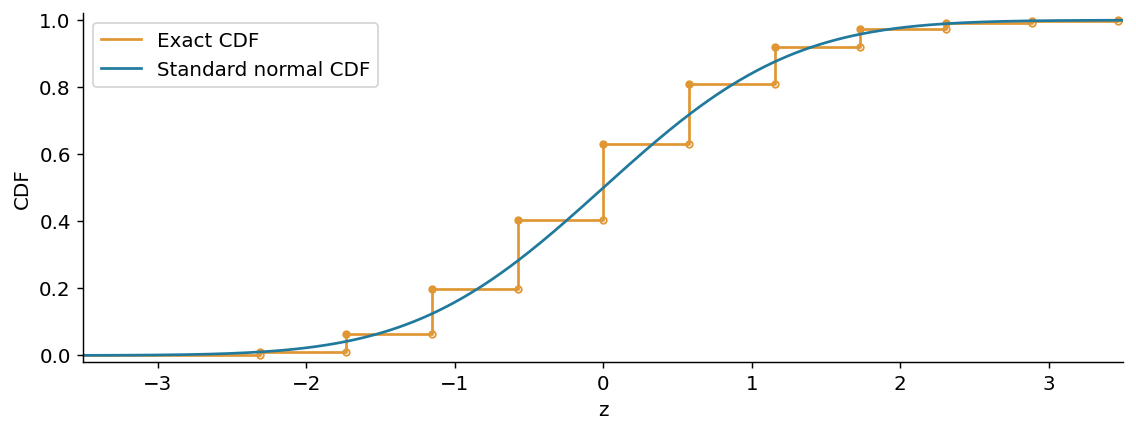

Rare p=.01, n=30, exact P(K=0): 0.7397003733882804
Any continuous CDF maximum error is at least: 0.3698501866941402


In [6]:
n=16; masses=np.array([float(q) for q in e.binomial_exact(n)])
z=(np.arange(n+1)-n/4)/math.sqrt(3*n/16)
cdf=np.cumsum(masses); before=np.r_[0,cdf[:-1]]
grid=np.linspace(-4,4,300)
fig,ax=plt.subplots(figsize=(9,3.6))
ax.step(np.r_[-5,z,7],np.r_[0,cdf,1],where="post",color="#df9633",label="Exact CDF")
ax.scatter(z,cdf,s=13,color="#df9633")
ax.scatter(z,before,s=13,facecolors="white",edgecolors="#df9633")
ax.plot(grid,[e.normal_cdf(float(v)) for v in grid],color="#217a9d",label="Standard normal CDF")
ax.set(xlim=(-3.5,3.5),ylim=(-.02,1.02),xlabel="z",ylabel="CDF")
ax.legend(); show(fig)
rare=Fraction(99,100)**30
print("Rare p=.01, n=30, exact P(K=0):",float(rare))
print("Any continuous CDF maximum error is at least:",float(rare/2))

### 6. Exponential原始数据不变为正态
只把每批均值中心化、标准化。每箱高度用计数/(全部4000×箱宽)，图外比例另报，不能删掉窗口外值后重新归一化。

4 fraction outside [-4,4]: 0.00425
256 fraction outside [-4,4]: 0.00025


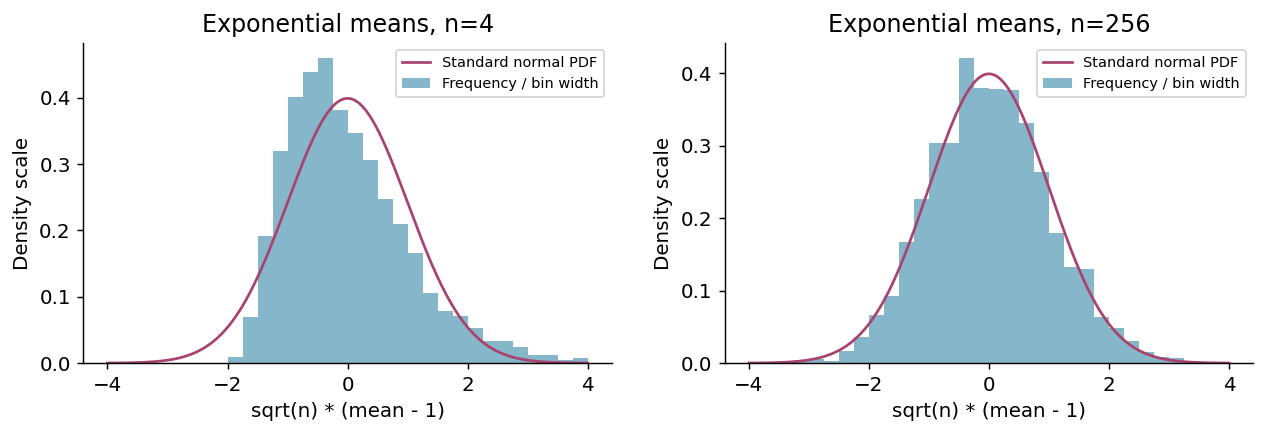

In [7]:
fig,axes=plt.subplots(1,2,figsize=(10,3.6)); edges=np.linspace(-4,4,33); grid=np.linspace(-4,4,300)
for ax,n in zip(axes,[4,256]):
    z=(samples["exponential"][n]-1)*math.sqrt(n)
    counts,_=np.histogram(z,bins=edges)
    density=counts/(len(z)*np.diff(edges))
    ax.bar((edges[:-1]+edges[1:])/2,density,width=np.diff(edges),alpha=.55,label="Frequency / bin width",color="#217a9d")
    ax.plot(grid,np.exp(-grid**2/2)/math.sqrt(2*math.pi),color="#a8426e",label="Standard normal PDF")
    ax.set(xlabel="sqrt(n) * (mean - 1)",ylabel="Density scale",title=f"Exponential means, n={n}")
    print(n,"fraction outside [-4,4]:",float(np.mean((z < -4)|(z > 4))))
    ax.legend(fontsize=8)
show(fig)

### 7. 群组依赖会被64行掩盖
64次独立抽样与8群组各复制8次的边缘分布相同，均值方差不同。模拟群组种子为基础seed+8000。

{'true_se': 0.15309310892394862, 'nominal_n': 64, 'independent_groups': 8, 'true_variance': 0.0234375, 'iid_variance_if_64': 0.0029296875, 'variance_inflation': 8}
Observed SD across cluster means: 0.15566503717722663
Average naive per-batch s/sqrt(64): 0.04797086491041831


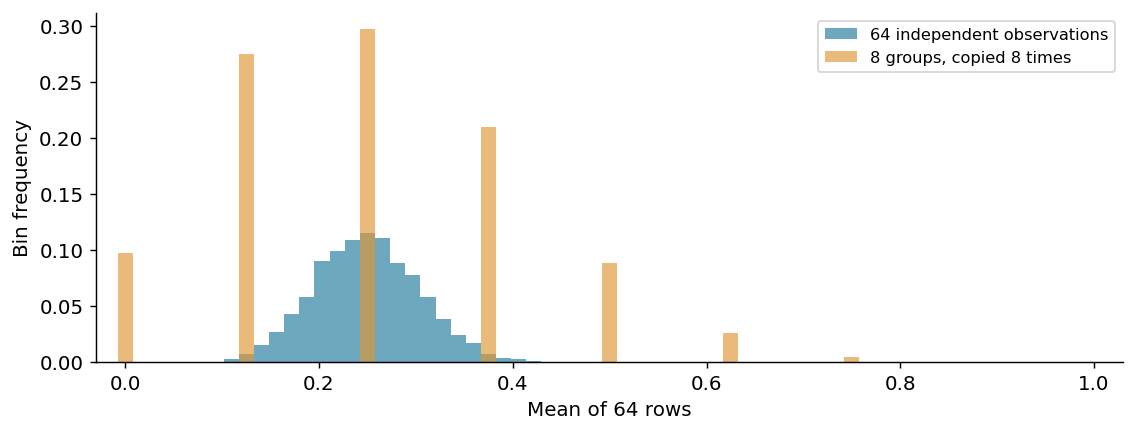

In [8]:
cluster=e.cluster_experiment(spec)
print({key:value for key,value in cluster.items() if key not in {"means","naive_se"}})
print("Observed SD across cluster means:",e.moments(cluster["means"])["s"])
print("Average naive per-batch s/sqrt(64):",float(cluster["naive_se"].mean()))
fig,ax=plt.subplots(figsize=(9,3.6)); bins=np.arange(-.0078125,1.008,.015625)
for values,label,color in [(samples["bernoulli"][64],"64 independent observations","#217a9d"),(cluster["means"],"8 groups, copied 8 times","#df9633")]:
    ax.hist(values,bins=bins,weights=np.ones(len(values))/len(values),alpha=.65,label=label,color=color)
ax.set(xlim=(-.03,1.03),xlabel="Mean of 64 rows",ylabel="Bin frequency")
ax.legend(fontsize=9); show(fig)

### 8. 有效样本量有模型与统计量限定
下面是已知等相关结构对均值的理论比较，不是由这批数据估计出的万能有效n。

In [9]:
print(e.mean_variance_equicorrelated(64,1,.2))
print("Lower PSD boundary, n=4:",e.mean_variance_equicorrelated(4,1,-1/3))
print("Full dependence:",e.mean_variance_equicorrelated(64,1,1))

{'variance_mean': 0.21250000000000002, 'design_effect': 13.600000000000001, 'effective_n_for_mean': 4.705882352941176}
Lower PSD boundary, n=4: {'variance_mean': 0.0, 'design_effect': 0.0, 'effective_n_for_mean': None}
Full dependence: {'variance_mean': 1.0, 'design_effect': 64.0, 'effective_n_for_mean': 1.0}


### 9. 不放回不是iid
同值不同身份继续保留。实际读取CSV值后枚举全部组合，完整抽样应没有均值不确定性。

In [10]:
print(e.finite_population_exact(population,2))
print(e.finite_population_exact(population,len(population)))

{'N': 4, 'n': 2, 'mean': '1/2', 'variance_N': '1/4', 'sample_mean_variance': '1/12', 'sample_means': ['0', '1/2', '1/2', '1/2', '1/2', '1']}
{'N': 4, 'n': 4, 'mean': '1/2', 'variance_N': '1/4', 'sample_mean_variance': '0', 'sample_means': ['1/2']}


### 10. 重尾的两个不同边界
Pareto I(3/2)有均值3却没有有限方差；Cauchy无通常期望。下面列出有限列表的描述统计，不能称其为总体均值/标准差的收敛估计。IQR使用NumPy linear分位数规则。

family    n    median     IQR     observed replicate SD
pareto_1_5 4 2.030151 1.218167 6.430537
pareto_1_5 16 2.378742 1.035509 8.480892
pareto_1_5 64 2.645263 0.779202 6.208045
pareto_1_5 256 2.772635 0.539797 1.197310
cauchy 4 -0.021907 1.999382 110.836468
cauchy 16 0.012698 2.023154 41.675703
cauchy 64 -0.025804 1.979874 87.580732
cauchy 256 -0.036351 2.019286 57.025010
Cauchy n 4 fraction outside displayed [-6,6]: 0.10475
Cauchy n 256 fraction outside displayed [-6,6]: 0.10475


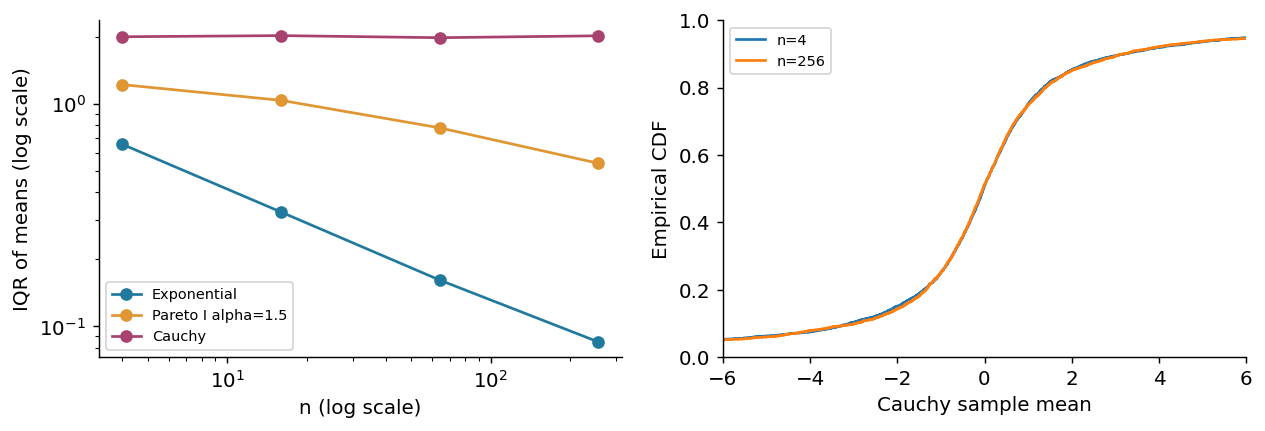

In [11]:
rows=e.summaries(samples)
print("family    n    median     IQR     observed replicate SD")
for row in rows:
    if row["family"] in {"pareto_1_5","cauchy"}:
        print(row["family"],row["n"],f'{row["median"]:.6f}',f'{row["iqr"]:.6f}',f'{row["replicate_sd"]:.6f}')
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for family,label,color in [("exponential","Exponential","#217a9d"),("pareto_1_5","Pareto I alpha=1.5","#df9633"),("cauchy","Cauchy","#a8426e")]:
    selected=[row for row in rows if row["family"]==family]
    axes[0].loglog([row["n"] for row in selected],[row["iqr"] for row in selected],"o-",label=label,color=color)
axes[0].set(xlabel="n (log scale)",ylabel="IQR of means (log scale)");axes[0].legend(fontsize=8)
for n in [4,256]:
    ordered=np.sort(samples["cauchy"][n]);axes[1].step(ordered,np.arange(1,len(ordered)+1)/len(ordered),where="post",label=f"n={n}")
    print("Cauchy n",n,"fraction outside displayed [-6,6]:",float(np.mean(np.abs(ordered)>6)))
axes[1].set(xlim=(-6,6),ylim=(0,1),xlabel="Cauchy sample mean",ylabel="Empirical CDF");axes[1].legend(fontsize=8)
show(fig)

### 11. 偏选可以精确地稳定在错误目标
这是给定的合成保留机制，不是从现实数据估计出的偏差。

In [12]:
p=Fraction(1,4); keep_if_one=Fraction(1);keep_if_zero=Fraction(1,3)
retained=p*keep_if_one+(1-p)*keep_if_zero
selected_p=p*keep_if_one/retained
print("Selected probability:",selected_p)
for n in [4,64,256]:
    mse=selected_p*(1-selected_p)/n+(selected_p-p)**2
    print("n",n,"MSE for target1/4",str(mse),float(mse))

Selected probability: 1/2
n 4 MSE for target1/4 1/8 0.125
n 64 MSE for target1/4 17/256 0.06640625
n 256 MSE for target1/4 65/1024 0.0634765625


## Checks
### 12. 可重复不代表前提正确
实际运行精确参考检查和边界检查。bool、文本、复数、非有限数和过大矩阵必须明确失败；不能悄悄删除或修改输入。

In [13]:
print("Reference checks:",e.reference_checks())
print("Boundary checks:",e.boundary_checks())
for label,call in [("mixed bool",lambda:e.moments([0,True])),("infinite",lambda:e.moments([0,float("inf")])),("not PSD",lambda:e.mean_variance_equicorrelated(4,1,-.5))]:
    try:call()
    except ValueError as error:print(label,"->",type(error).__name__,str(error))
    else:raise ValueError("Expected rejection")

Reference checks: 268
Boundary checks: {'expected_rejections': 55, 'accepted_groups': 14, 'groups': 69}
mixed bool -> ValueError observation must be a real number, not bool/text/complex
infinite -> ValueError observation outside finite teaching range
not PSD -> ValueError equicorrelation matrix is not PSD


## Next Steps
先完成answers.pdf的16题，再修改一个前提，预测变化，最后运行核验。不要同时改分布、n、R和采样设计后仅凭一张图判断原因。

本Notebook已在新的Python进程与真实InProcessKernel顺序执行；浏览器Jupyter界面、常规socket传输及读者Anaconda安装未测试。有限模拟不证明极限定理，不检验真实业务iid性，也不提供未经推导的置信区间。来源和数学证明范围见lecture.pdf及source-checks.json。